# 1. EDA

Missing values, target class balance, key variable relationships, collinearity, categorical cardinality, and a structural-zero check on 1st semester grades.

In [1]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocessing import (
    CATEGORICAL_COLS,
    NUMERIC_COLS,
    TARGET_COL,
    load_data,
)

sns.set_theme(style="whitegrid")
df = load_data()
df.shape


(4424, 37)

## 1.1 Missing values

In [2]:
df.isna().sum().sum()  # check for missing values

np.int64(0)

## 1.2 Target class balance

Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


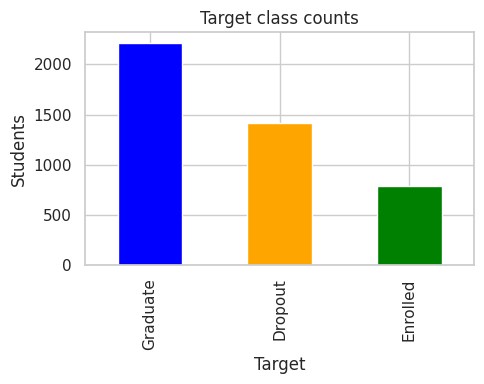

In [3]:
counts = df[TARGET_COL].value_counts()
proportions = df[TARGET_COL].value_counts(normalize=True).round(3)
print(proportions)

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", ax=ax, color=["blue", "orange", "green"])
ax.set_title("Target class counts")
ax.set_ylabel("Students")
plt.tight_layout()
plt.show()

# notice the imbalance in the target classes
# 50% Graduate, 32% Dropout, 18% Enrolled
# this is why the modeling step uses class_weight='balanced'
# otherwise, a model could hit about 70% accuracy by predicting the majority class (Graduate)


## 1.3 Key numeric variables vs. Target

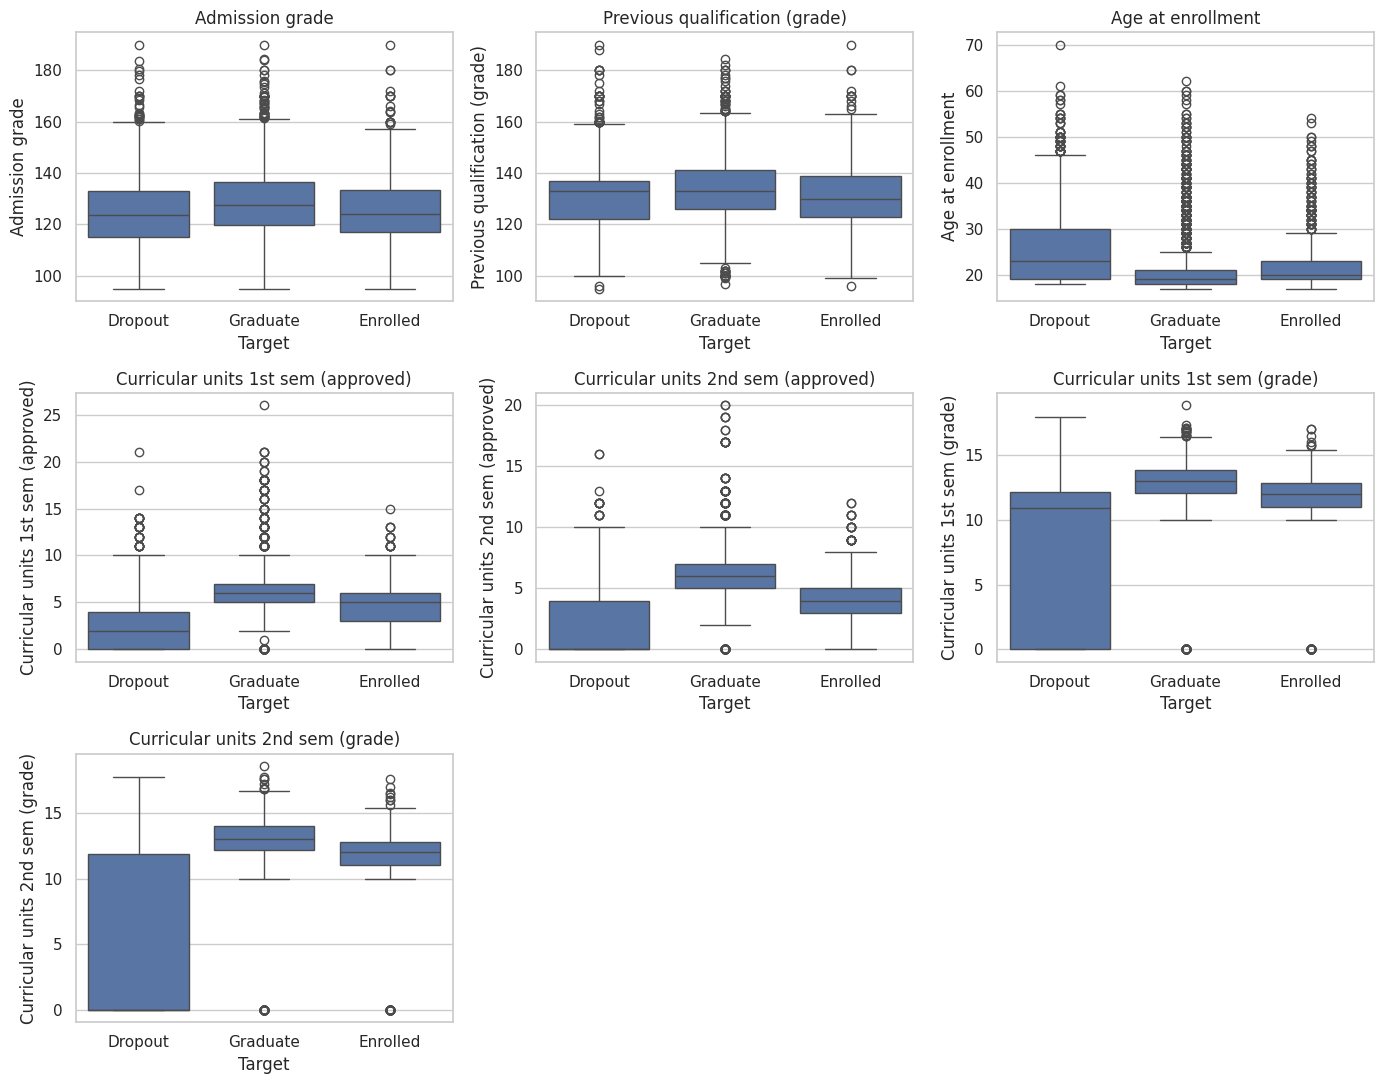

In [4]:
key_numeric_cols = [
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 11))
for ax, col in zip(axes.flat, key_numeric_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(key_numeric_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## 1.4 Key categorical/binary variables vs. Target

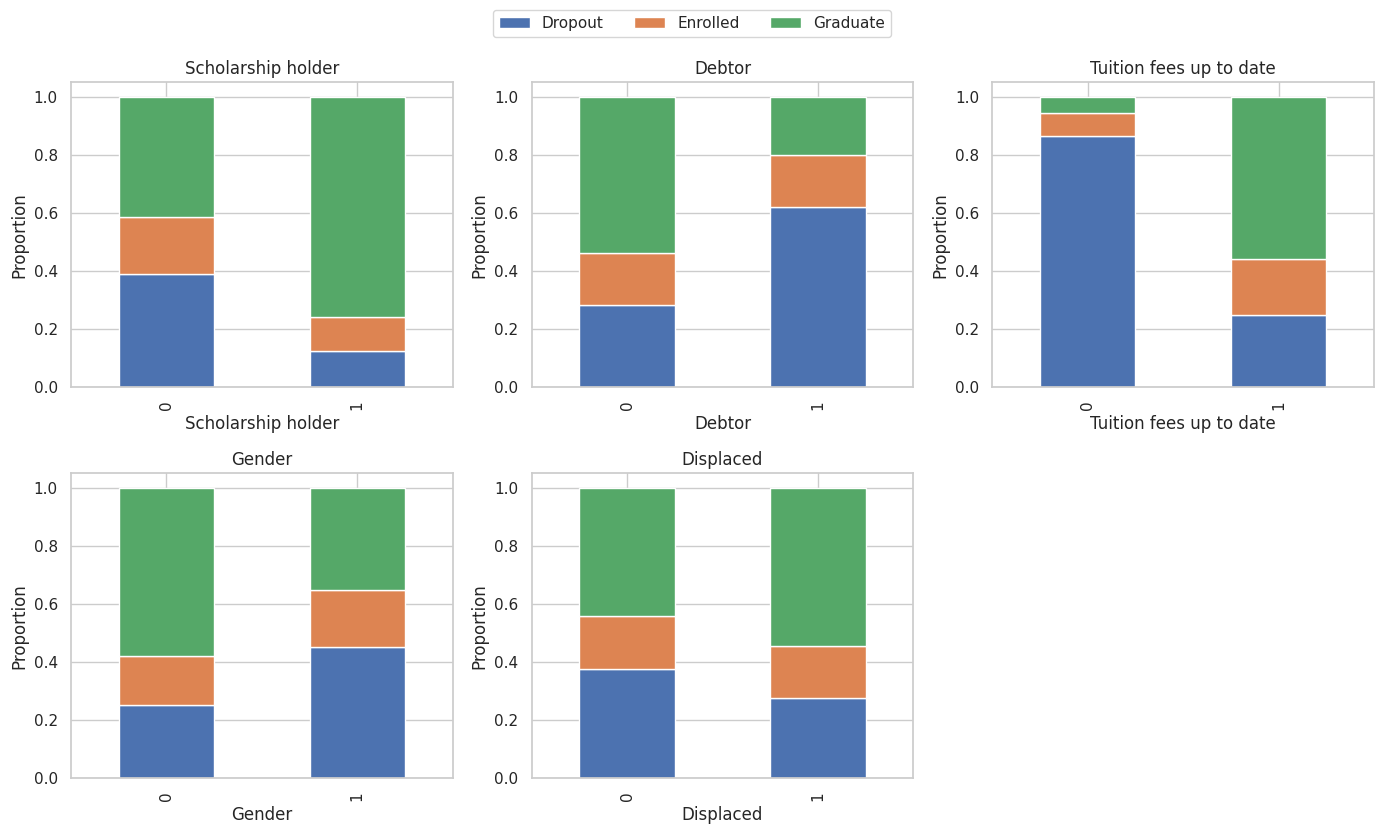

In [5]:
key_categorical_cols = ["Scholarship holder", "Debtor", "Tuition fees up to date", "Gender", "Displaced"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_categorical_cols):
    rates = pd.crosstab(df[col], df[TARGET_COL], normalize="index")
    rates.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05))
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


## 1.5 Correlation and collinearity
### 1.5.1 Parental variables

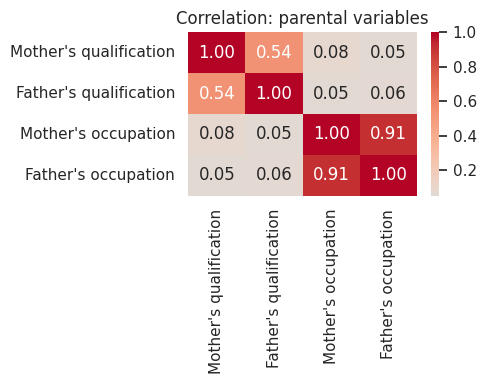

In [6]:
parent_education_cols = ["Mother\'s qualification", "Father\'s qualification",
               "Mother\'s occupation", "Father\'s occupation"]

corr = df[parent_education_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: parental variables")
plt.tight_layout()
plt.show()


### 1.5.2 Full numeric correlation heatmap

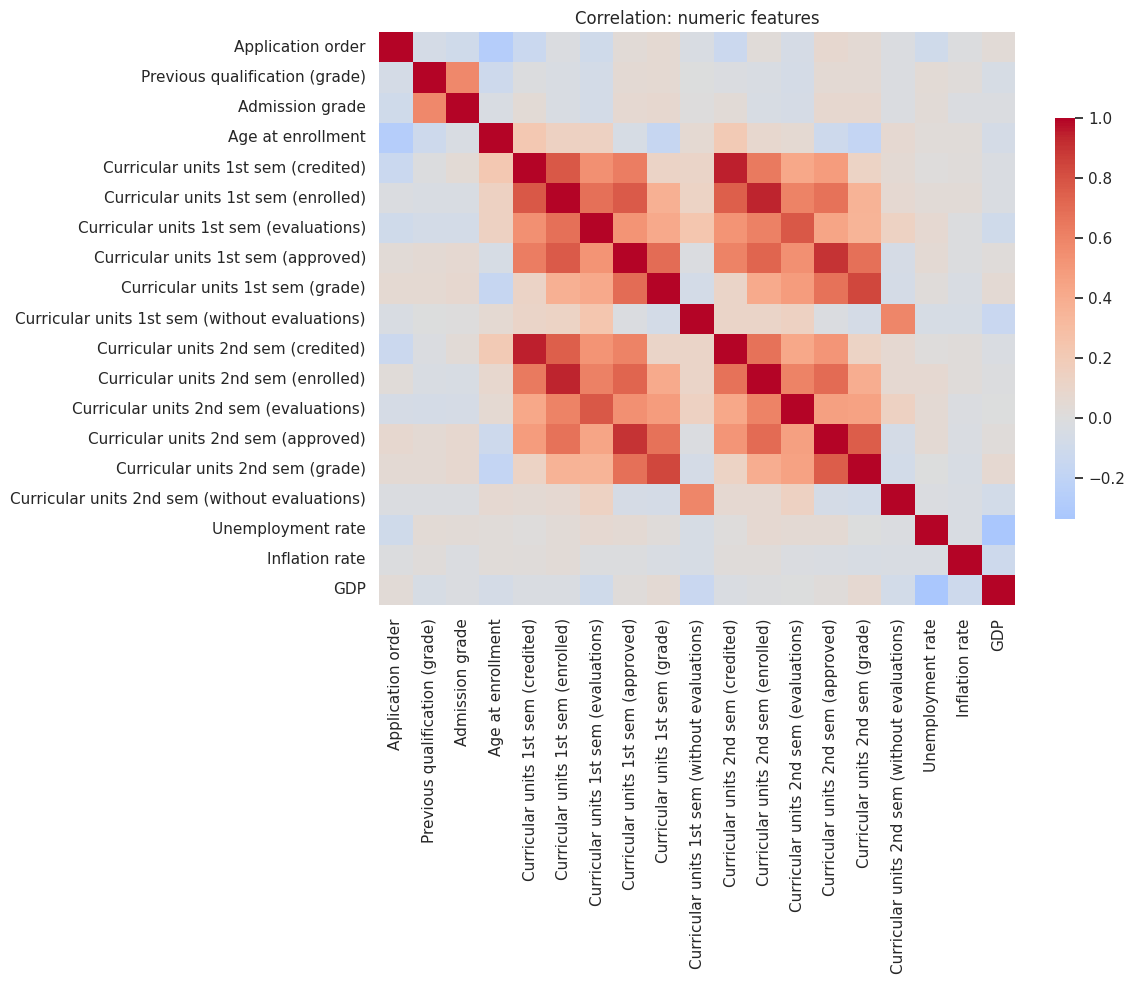

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[NUMERIC_COLS].corr(), cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation: numeric features")
plt.tight_layout()
plt.show()


## 1.6 Categorical feature cardinality

Father's occupation       46
Father's qualification    34
Mother's occupation       32
Mother's qualification    29
Nacionality               21
Application mode          18
Previous qualification    17
Course                    17
Marital status             6
dtype: int64

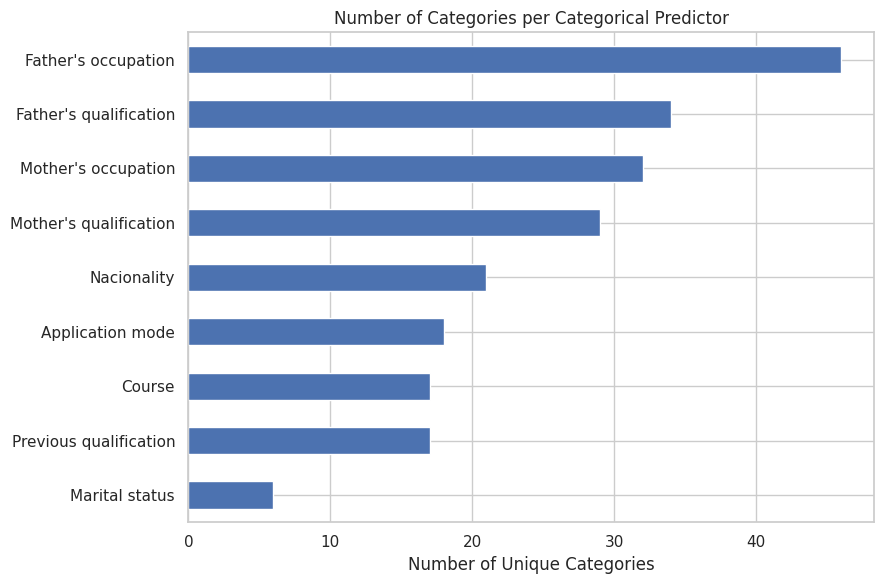

In [8]:
category_cardinality = (
    df[CATEGORICAL_COLS]
    .nunique()
    .sort_values(ascending=False)
)

display(category_cardinality)

fig, ax = plt.subplots(figsize=(9, 6))
category_cardinality.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Number of Categories per Categorical Predictor")
ax.set_xlabel("Number of Unique Categories")
plt.tight_layout()
plt.show()


## 1.7 Structural zero analysis

Students with Semester 1 grade = 0: 718
Proportion with Semester 1 grade = 0: 16.230%


Target,Dropout,Enrolled,Graduate
Sem1 grade zero,,,
0,0.230,0.195,0.575
1,0.794,0.099,0.107


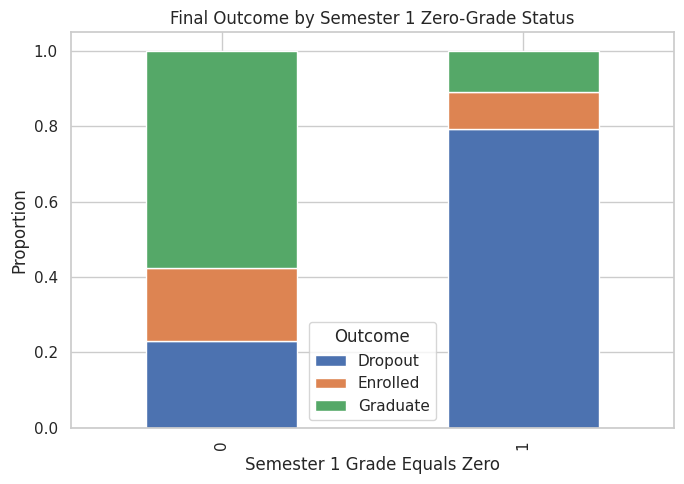

In [9]:
sem1_grade_col = "Curricular units 1st sem (grade)"

n_zero = (df[sem1_grade_col] == 0).sum()
prop_zero = (df[sem1_grade_col] == 0).mean()

print(f"Students with Semester 1 grade = 0: {n_zero}")
print(f"Proportion with Semester 1 grade = 0: {prop_zero:.3%}")

# Temporary indicator, used only in this EDA cell -- not carried into
# any other notebook or the feature-availability column sets.
df["Sem1 grade zero"] = (df[sem1_grade_col] == 0).astype(int)

zero_grade_outcomes = pd.crosstab(df["Sem1 grade zero"], df[TARGET_COL], normalize="index")
display(zero_grade_outcomes.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
zero_grade_outcomes.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Final Outcome by Semester 1 Zero-Grade Status")
ax.set_xlabel("Semester 1 Grade Equals Zero")
ax.set_ylabel("Proportion")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()
